# Preliminary Analysis of HARP2 data 

In [1]:
import earthaccess
import xarray as xr
import netCDF4
import os,re,copy,glob
import numpy as np
import matplotlib.pyplot as plt
import pickle 
import cartopy
import sys,os
import cartopy.crs as crs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
# import awscli, s3fs, boto3
# import requests
import logging

import warnings
warnings.filterwarnings("ignore")

## Download Data 

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
# results = earthaccess.search_datasets(instrument="harp2")
# for item in results:
#     summary = item.summary()
#     print(summary["short-name"])

In [ ]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_CLOUD_MASK", 
    # short_name="PACE_OCI_L2_CLOUD",
    # temporal=("2025-07-01", "2025-07-31"),
    temporal=("2025-07-06T19:20:50", "2025-07-06T19:25:49"),
    # granule_name="*L1B*.nc"    # "*L1C*.5km*.nc"
    count=1
)

In [ ]:
files = earthaccess.download(results, "/umbc/rs/zzbatmos/common/Data/PACE/PACE_OCI_CLD_PROP")

### Load PACE Utility functions 

In [2]:
import PACE_Util

In [3]:
PACE_data_path_taki = '/umbc/rs/zzbatmos/common/Data/PACE/'
PACE_OCI_L1B_data_path = os.path.join(PACE_data_path_taki,'PACE_OCI_L1B_SCI/')
PACE_OCI_L1C_data_path = os.path.join(PACE_data_path_taki,'PACE_OCI_L1C_SCI/')
PACE_HARP2_L1C_data_path = os.path.join(PACE_data_path_taki,'PACE_HARP2_L1C_SCI/')
PACE_OCI_L2_cloud_data_path = os.path.join(PACE_data_path_taki,'PACE_OCI_CLD_PROP/')

In [5]:
ts='20250706T192050'
H1C= PACE_Util.HARP2_L1(ts, data_level='L1C', data_path = PACE_HARP2_L1C_data_path, spr=True)
oci_l1b_granuel = PACE_Util.OCI_Level1B(ts, data_path= PACE_OCI_L1B_data_path)
oci_l1c_granuel = PACE_Util.OCI_Level1C(ts, data_path= PACE_OCI_L1C_data_path)
oci_l2cld_granuel = PACE_Util.OCI_L2_CLD(ts, data_path= PACE_OCI_L2_cloud_data_path)

### Plot RGB image based on HARP2 radiance observations

In [ ]:
# to get pixels
plt.figure(figsize=(8,6))
img = plt.imshow(H1C.observation_data.q, cmap='viridis', vmin=3, vmax=15, origin='lower')
plt.title('HARP2 CER', color='k', fontweight='bold')
plt.colorbar(img, extend='both', label='CER', ticks=np.arange(3, 16, 3))
plt.show()

In [ ]:
# Find red dot pixel
lat_target = -20.0   # -18
lon_target = -91.5   # -91.85

lat = H1C.geolocation_data.latitude   # shape (396, 519)
lon = H1C.geolocation_data.longitude  # shape (396, 519)

# compute squared distance to target
dist = (lat - lat_target)**2 + (lon - lon_target)**2

# find nearest pixel
iy, ix = np.where(dist == np.min(dist))

print("Red dot pixel HARP2:", ix[0], iy[0])

In [2]:
# H1C.observation_data.q.shape
# help(H1C.plot_true_color_RGB)

In [7]:
# H1C.plot_true_color_RGB(figsize=[8, 6], x0_indices=[292], y0_indices=[231])     # 289, 188

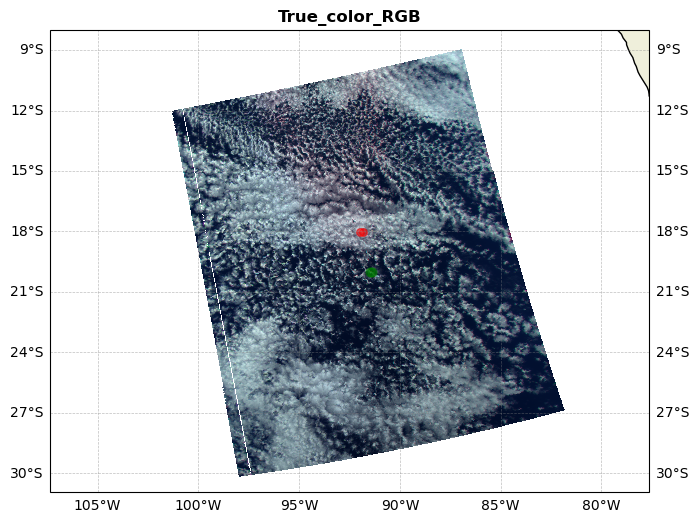

In [8]:
H1C.plot_true_color_RGB(figsize=[8, 6], x0_indices=[292, 289], y0_indices=[231, 188], markers=["o", "o"], 
                        colors=["r", "g"], sizes=[30, 40])

### Plot RGB image based on OCI radiance observations 

In [9]:
# dir(oci_l1b_granuel)
# [attr for attr in dir(oci_l1b_granuel) if not attr.startswith("_")]

In [10]:
# Find red dot pixel
lat_target = -18.0   
lon_target = -91.85   

lat = oci_l1b_granuel.geo.latitude   
lon = oci_l1b_granuel.geo.longitude 

# compute squared distance to target
dist = (lat - lat_target)**2 + (lon - lon_target)**2

# find nearest pixel
iy, ix = np.where(dist == np.min(dist))

print("Red dot pixel OCI:", ix[0], iy[0])

Red dot pixel OCI: 781 1206


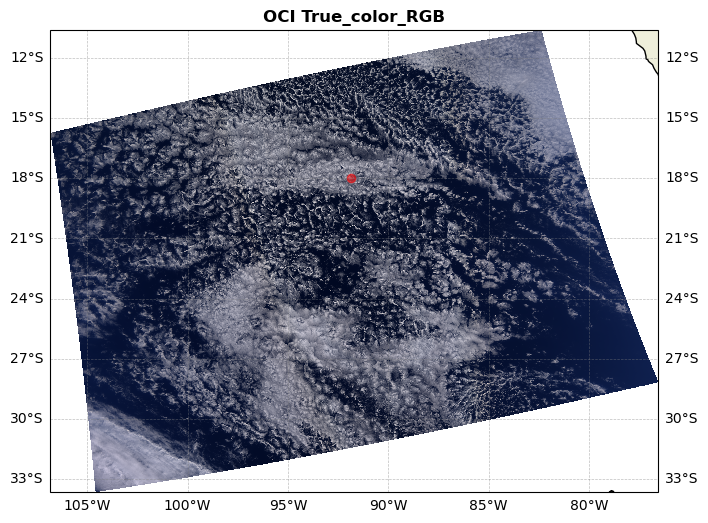

In [11]:
oci_l1b_granuel.plot_true_color_RGB(figsize=[8, 6], x0_indices=[781], y0_indices=[1206]) 

In [12]:
y0,x0 = 1206,781   
y1,x1 = 1020,770

print(f'CER of pixel: {oci_l2cld_granuel.cld_prop.cer_21[y0-2:y0+2,x0-2:x0+2].values}')
print(f'COT of pixel: {oci_l2cld_granuel.cld_prop.cot_21[y0-2:y0+2,x0-2:x0+2].values}')
print('')
print(f'CER of pixel: {oci_l2cld_granuel.cld_prop.cer_21[y1-2:y1+2,x1-2:x1+2].values}')
print(f'COT of pixel: {oci_l2cld_granuel.cld_prop.cot_21[y1-2:y1+2,x1-2:x1+2].values}')

CER of pixel: [[14.667969  14.714844  14.722656  14.839844 ]
 [15.238281  15.121094  14.925781  14.738281 ]
 [15.7109375 15.878906  15.234375  14.3359375]
 [15.15625   15.3828125 14.566406  14.082031 ]]
COT of pixel: [[17.191206 18.197067 17.035074 18.92479 ]
 [19.353336 18.816998 15.633308 14.508652]
 [27.66292  25.269836 29.913721 17.578934]
 [39.821125 37.05418  28.488697 17.83759 ]]

CER of pixel: [[28.40964        nan 21.648438 23.023438]
 [29.917685 26.       23.609375 24.554688]
 [25.96875  21.53125  24.789062 23.570312]
 [19.304688 18.71875  23.414062 24.4375  ]]
COT of pixel: [[ 2.5381143        nan  1.0056787  3.5440803]
 [ 2.9168444  2.311012   1.8733265  6.7161145]
 [ 3.8341954  3.4936805  4.217967  11.296986 ]
 [ 5.62531    5.03712    6.854848  15.018272 ]]


In [13]:
# oci_l1b_granuel.sbp

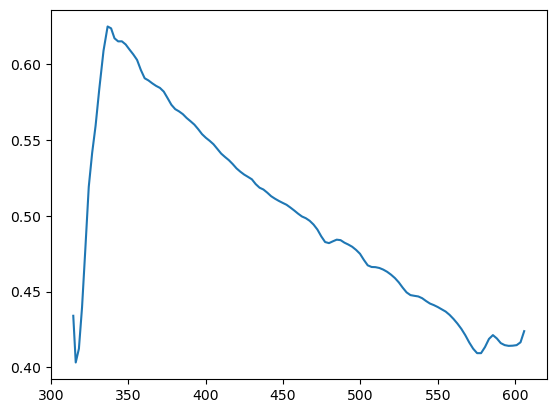

In [13]:
fig,ax=plt.subplots()
ax.plot(oci_l1b_granuel.sbp.blue_wavelength,oci_l1b_granuel.obs.rhot_blue[:,231,292])

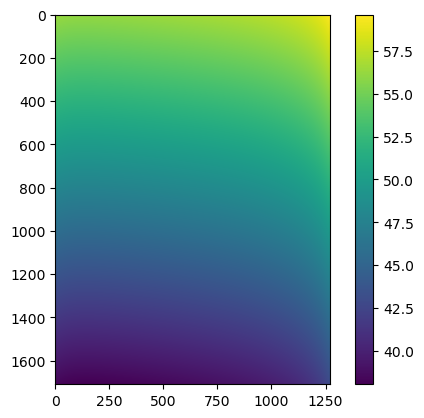

In [14]:
fig,ax=plt.subplots()
cf=ax.imshow(oci_l1b_granuel.geo.solar_zenith)
plt.colorbar(cf)

### 1. Cloud Phase,    2. COT,    3. CER 

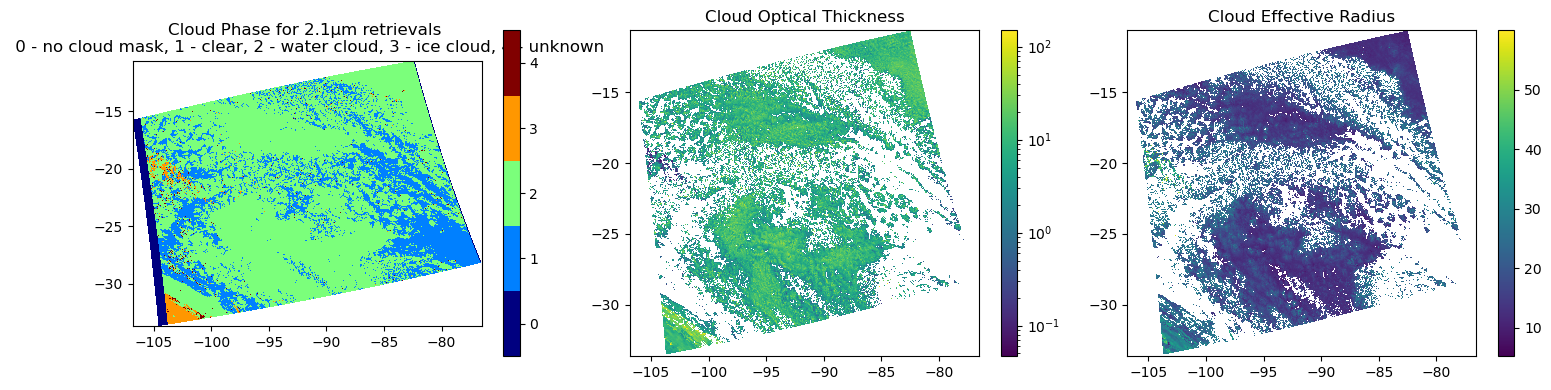

In [15]:
oci_l2cld_granuel.plot_cloud_prop()

### RGB based on DoLP Degree of Linear Polarization

In [16]:
H1C.observation_data.q.shape

(396, 519, 90, 1)

In [17]:
# oci_l1b_granuel.geo
# list(oci_l1b_granuel.geo.data_vars)
oci_l1b_granuel.geo['sensor_zenith'].shape

(1710, 1272)

### Arrangement of multi-angular observations from HARP2

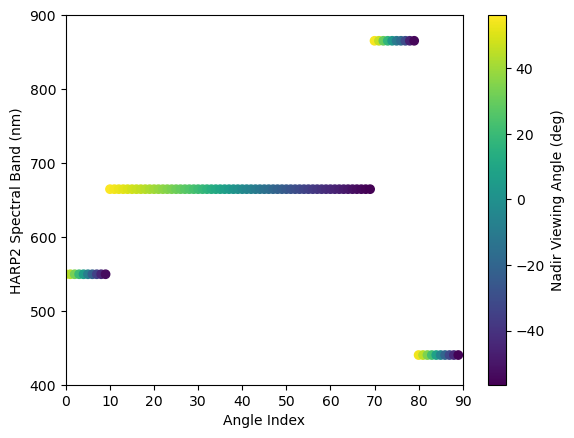

In [18]:
num_angles = H1C.sensors_views_bands.sensor_view_angle.size

#plot the distribution of angles, bands, and indices
fig,ax=plt.subplots()
cf=ax.scatter(np.linspace(0,num_angles-1,num_angles),H1C.sensors_views_bands.intensity_wavelength,
              c=H1C.sensors_views_bands.sensor_view_angle)
ax.set_xlabel("Angle Index")
ax.set_ylabel("HARP2 Spectral Band (nm)")
ax.set_ylim(400,900)
ax.set_xlim(0,90)
plt.colorbar(cf,label="Nadir Viewing Angle (deg)",ax=ax)

In [19]:
# H1C.sensors_views_bands.intensity_wavelength[80:90].values

In [20]:
y0_index,x0_index = 231,292 # 188,289
# y1_index,x1_index = 188,289

1 10
[664.564]


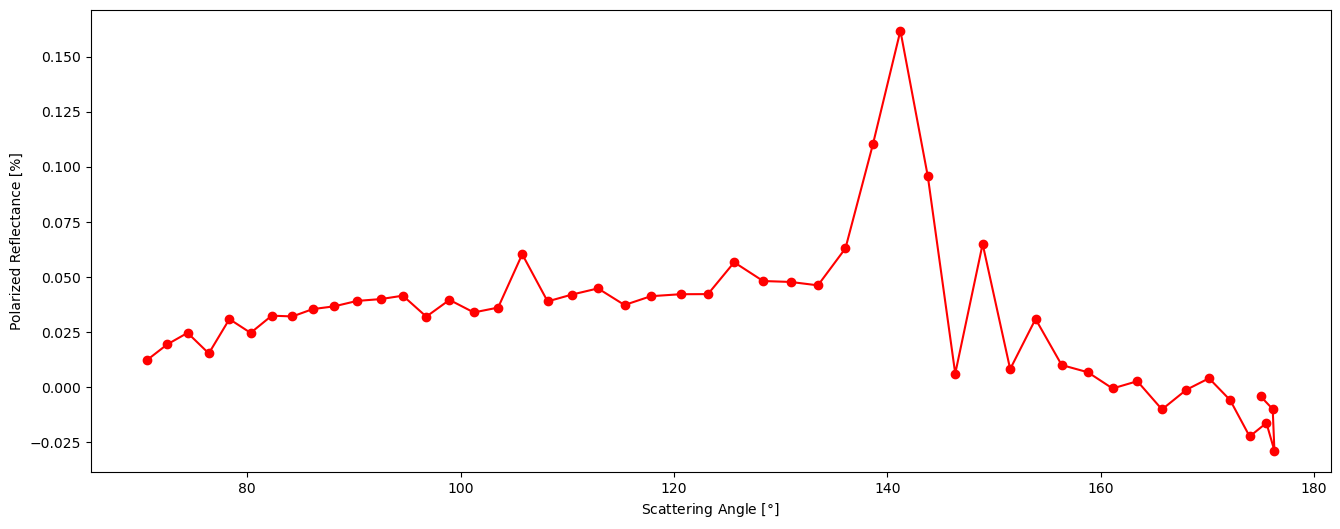

In [21]:
angle_range=[0,10,60,80,90]
color_index = ['b','g','r','tab:purple']

fig, ax=plt.subplots(figsize=(16,6))
# ax.set_xlim([60,180])
ax.set_xlabel(r'Scattering Angle [$\degree$]')
ax.set_ylabel('Polarized Reflectance [%]')       # Normalized I_p

ia = 1
print(ia, angle_range[ia])
al = angle_range[ia]
ar = angle_range[ia+1]

print(H1C.sensors_views_bands.intensity_wavelength[al].values)
label_text=('{0:5.2f} nm'.format(H1C.sensors_views_bands.intensity_wavelength[al].values[0]))


ax.plot(H1C.geolocation_data.scattering_angle[y0_index,x0_index,al:ar],
        H1C.q_s_norm[y0_index,x0_index,al:ar], label=label_text, c='r', marker='o', markersize=6)
        # c=color_index[ia]

## Compare clean and ACA cloud scences

In [22]:
HARP2_L1C_clean= '20250706T192050' # good StCu cloud case

HARP2_L1C_ACA= '20250706T192050' # ACA cloud case

H1C_clean= PACE_Util.HARP2_L1(HARP2_L1C_clean, data_level='L1C',data_path = PACE_HARP2_L1C_data_path, spr=True)
H1C_ACA=   PACE_Util.HARP2_L1(HARP2_L1C_ACA, data_level='L1C',data_path = PACE_HARP2_L1C_data_path, spr=True)

In [23]:
# H1C_clean.observation_data

In [24]:
x0_clean, y0_clean = 292, 231 
x0_clean, y0_clean = 289, 188 
x0_ACA, y0_ACA = 289, 188

### Plot the RGB image of the two cases

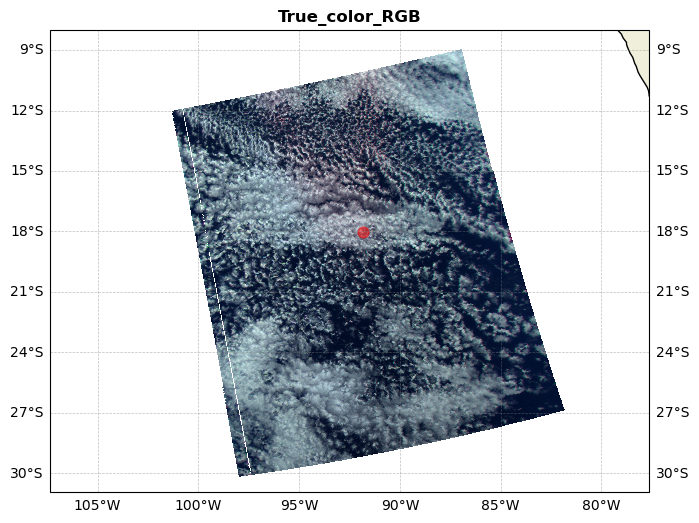

In [25]:
H1C_clean.plot_true_color_RGB(figsize=[8, 6], x0_indices=[x0_clean], y0_indices=[y0_clean], save_RGB=False)
#plt.savefig('HARP-2_RGB.png',dpi=300)

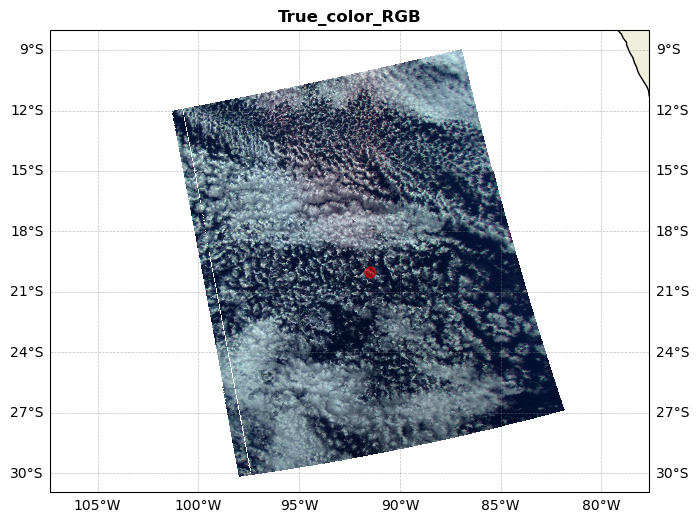

In [26]:
H1C_ACA.plot_true_color_RGB(figsize=[8, 6], x0_indices=[x0_ACA], y0_indices=[y0_ACA], colors='g')

1 10
[664.564]


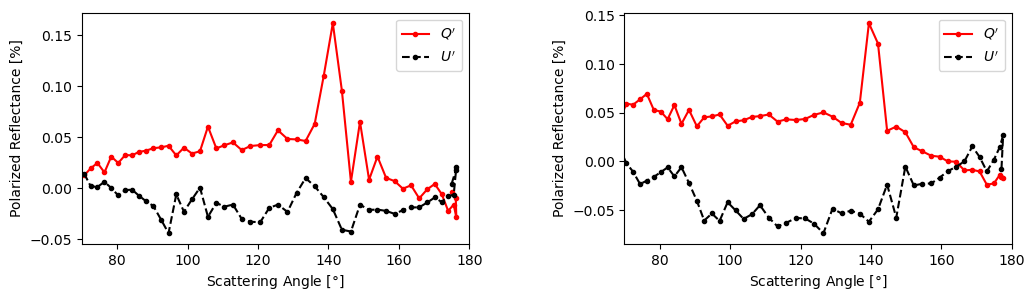

In [27]:
angle_range=[0,10,60,80,90]
color_index = ['b','g','r','tab:purple']

fig,ax=plt.subplots(1,2,figsize=(12,3))
fig.subplots_adjust(wspace=0.4)

ax[0].set_xlim([70,180])
ax[1].set_xlim([70,180])

ax[0].set_xlabel(r'Scattering Angle [$\degree$]')
ax[0].set_ylabel(r'Polarized Reflectance [%]')
ax[1].set_xlabel(r'Scattering Angle [$\degree$]')
ax[1].set_ylabel(r'Polarized Reflectance [%]')

for ia in range(1,2):
    print(ia,angle_range[ia])
    al = angle_range[ia]
    ar = angle_range[ia+1]
    print(H1C_clean.sensors_views_bands.intensity_wavelength[al].values)
    label_text=('{0:5.2f} nm'.format(H1C_clean.sensors_views_bands.intensity_wavelength[al].values[0]))
    ax[0].plot(H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar], 
               H1C_clean.q_s_norm[y0_clean,x0_clean,al:ar], label=r"$Q'$", c='r', marker='.', markersize=6)
    ax[0].plot(H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar], 
               H1C_clean.u_s_norm[y0_clean,x0_clean,al:ar], label=r"$U'$", c='k',marker='.', 
               markersize=6, ls='dashed')
    
    ax[1].plot(H1C_ACA.geolocation_data.scattering_angle[y0_ACA,x0_ACA,al:ar], 
               H1C_ACA.q_s_norm[y0_ACA,x0_ACA,al:ar], label=r"$Q'$", c='r', marker='.', markersize=6)
    ax[1].plot(H1C_ACA.geolocation_data.scattering_angle[y0_ACA,x0_ACA,al:ar], 
               H1C_ACA.u_s_norm[y0_ACA,x0_ACA,al:ar], label=r"$U'$", c='k', marker='.', 
               markersize=6, ls='dashed')

ax[0].legend(loc=0)
ax[1].legend(loc=0)

1 10
[664.564]


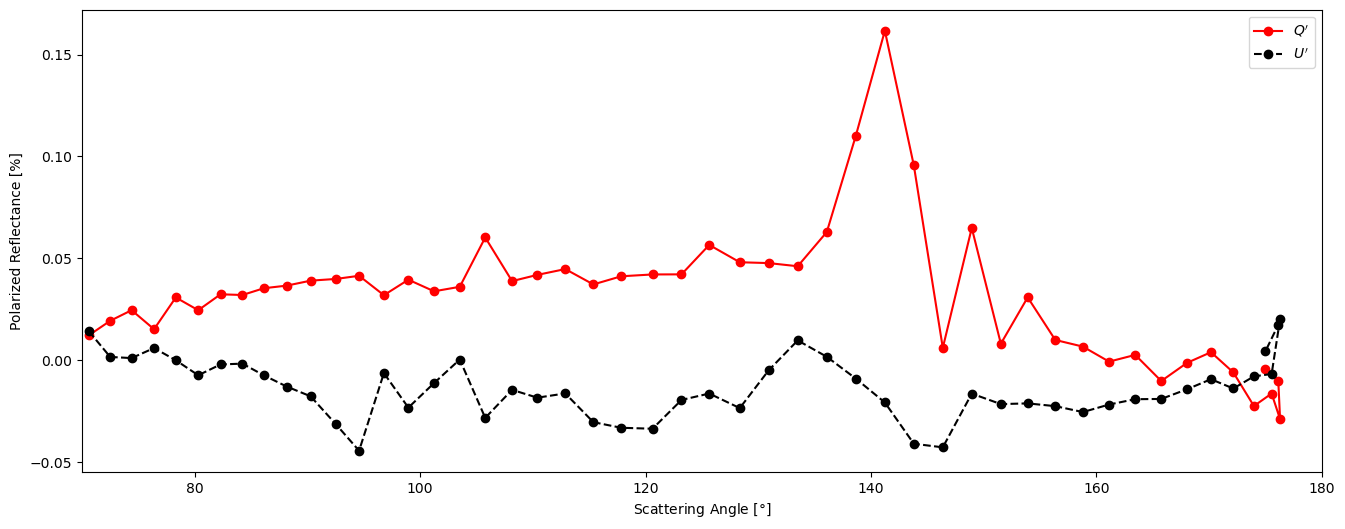

In [28]:
angle_range = [0, 10, 60, 80, 90]
color_index = ['b', 'g', 'r', 'tab:purple']

fig, ax = plt.subplots(figsize=(16, 6))  
ax.set_xlim([70, 180])

ax.set_xlabel(r'Scattering Angle [$\degree$]')
ax.set_ylabel('Polarized Reflectance [%]')     # r'Normalized $I_p$ [%]'

for ia in range(1, 2):
    print(ia, angle_range[ia])
    al = angle_range[ia]
    ar = angle_range[ia + 1]
    print(H1C_clean.sensors_views_bands.intensity_wavelength[al].values)

    label_text = ('{0:5.2f} nm'.format(H1C_clean.sensors_views_bands.intensity_wavelength[al].values[0]))

    # q_s_norm
    ax.plot(H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar],
            H1C_clean.q_s_norm[y0_clean, x0_clean, al:ar], label=r"$Q'$", c='r', marker='o')

    # u_s_norm
    ax.plot(H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar],
            H1C_clean.u_s_norm[y0_clean, x0_clean, al:ar], label=r"$U'$", c='k', marker='o', ls='dashed')

ax.legend(loc=0)
# plt.savefig("Normalized Q (Good).png", dpi=500, bbox_inches="tight")

1 10
[664.564]


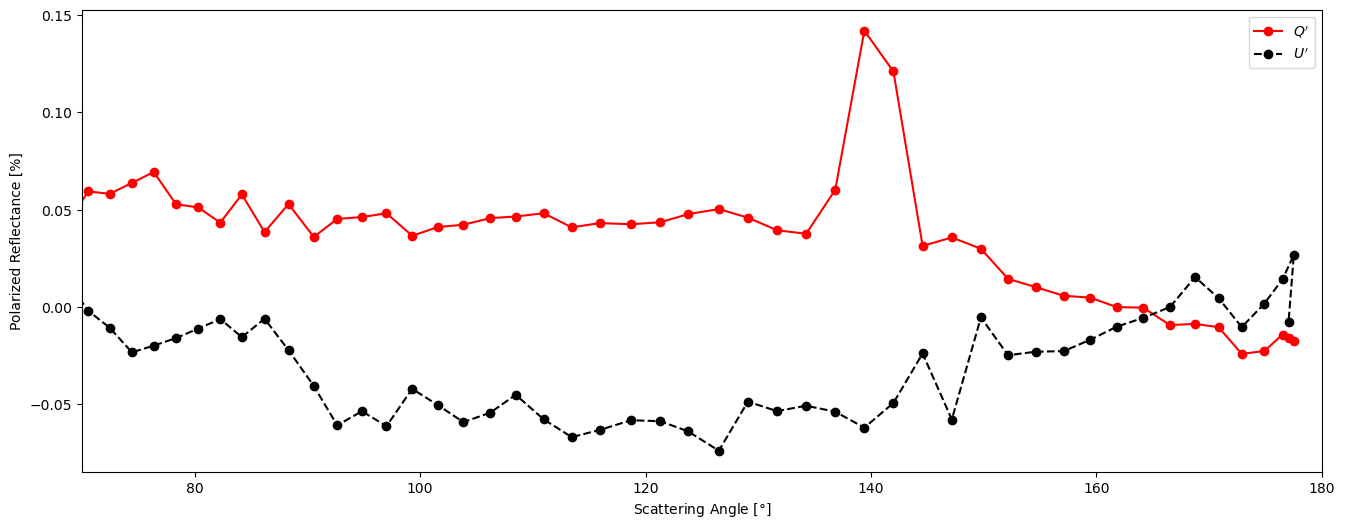

In [29]:
angle_range = [0, 10, 60, 80, 90]
color_index = ['b', 'g', 'r', 'tab:purple']

fig, ax = plt.subplots(figsize=(16, 6))  
ax.set_xlim([70, 180])

ax.set_xlabel(r'Scattering Angle [$\degree$]')
ax.set_ylabel('Polarized Reflectance [%]')   # r'Normalized $I_p$ [%]'

for ia in range(1, 2):
    print(ia, angle_range[ia])
    al = angle_range[ia]
    ar = angle_range[ia + 1]
    print(H1C_ACA.sensors_views_bands.intensity_wavelength[al].values)

    label_text = ('{0:5.2f} nm'.format(H1C_clean.sensors_views_bands.intensity_wavelength[al].values[0]))

    # q_s_norm
    ax.plot(H1C_ACA.geolocation_data.scattering_angle[y0_ACA, x0_ACA, al:ar],
            H1C_ACA.q_s_norm[y0_ACA, x0_ACA, al:ar], label=r"$Q'$", c='r', marker='o')

    # u_s_norm
    ax.plot(H1C_ACA.geolocation_data.scattering_angle[y0_ACA, x0_ACA, al:ar],
            H1C_ACA.u_s_norm[y0_ACA, x0_ACA, al:ar], label=r"$U'$", c='k', marker='o', ls='dashed')

ax.legend(loc=0)
# plt.savefig("Normalized Q (Bad).png", dpi=500, bbox_inches="tight")

## Load Polarized Scattering Phase Functions of water droplets for re and ve retrievals

In [30]:
class Water_Cloud_LUT():
    def __init__(self,LUT_nc_filename,LUT_par_list):
        ncf = netCDF4.Dataset(LUT_nc_filename,'r')
        self.LUT_par_dict={}
        for par in LUT_par_list:
            print('reading',par)
            self.LUT_par_dict[par]=np.array(ncf.variables[par])
            
LUT_ncfile='/umbc/rs/zzbatmos/common/Data/Polarized_Droplet_Single_Scattering_Properties_for_PARASOL.nc'
LUT_par_list=['band_center', 're','veff','scattering_angle','P11','P12']
WC_LUT=Water_Cloud_LUT(LUT_ncfile, LUT_par_list)

reading band_center
reading re
reading veff
reading scattering_angle
reading P11
reading P12


In [31]:
for k in WC_LUT.LUT_par_dict.keys():
    print(k,WC_LUT.LUT_par_dict[k].shape,WC_LUT.LUT_par_dict[k].min(),WC_LUT.LUT_par_dict[k].max())

band_center (4,) 0.443 0.865
re (197,) 1.0 50.0
veff (11,) 0.01 0.10999999
scattering_angle (1801,) 0.0 180.0
P11 (4, 11, 197, 1801) 0.012604483 236919.72
P12 (4, 11, 197, 1801) -3.349194 5.455567


In [32]:
print(WC_LUT.LUT_par_dict['band_center'])

[0.443 0.49  0.67  0.865]


In [33]:
iwl=2
ire=np.searchsorted(WC_LUT.LUT_par_dict['re'],[5,15,30])
ive=np.searchsorted(WC_LUT.LUT_par_dict['veff'],[0.01,0.05,0.1])
print(ire)
print(ive)

[ 16  56 116]
[ 1  5 10]


Text(122, 0.52, 'b)')

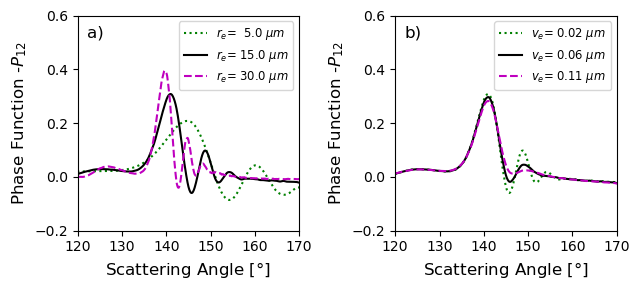

In [34]:
fig,ax=plt.subplots(1,2,figsize=[6.5,3],tight_layout=True)
ls=['dotted','solid','dashed']
color=['g','k','m']
n=0
for i in ire:
    ax[0].plot(WC_LUT.LUT_par_dict['scattering_angle'], -WC_LUT.LUT_par_dict['P12'][iwl,ive[0],i,:],
               ls=ls[n],c=color[n],label=r'$r_e$={0:5.1f} $\mu m$'.format(WC_LUT.LUT_par_dict['re'][i]))
    n+=1
n=0
for j in ive:
    ax[1].plot(WC_LUT.LUT_par_dict['scattering_angle'], -WC_LUT.LUT_par_dict['P12'][iwl,j,ire[1],:],
               ls=ls[n],c=color[n],label=r'$v_e$={0:5.2f} $\mu m$'.format(WC_LUT.LUT_par_dict['veff'][j]))  
    n+=1
for axis in ax:
    axis.legend(loc=0,ncol=1,fontsize='small')
    axis.set_xlim([120,170])
    axis.set_ylim([-0.2,0.6])
    axis.set_xlabel(r'Scattering Angle [$\degree$]',fontsize='large')
    axis.set_ylabel(r'Phase Function -$P_{12}$',fontsize='large')
ax[0].text(122,0.52,'a)',fontsize='large')
ax[1].text(122,0.52,'b)',fontsize='large')
# fig.savefig('HARP_CER_CER_retrieval_illustration.png', dpi=500, bbox_inches="tight")

In [35]:
# This algorithm fits observed polarized reflectance to precomputed polarized phase functions LUT
def Rp_mod(x,a,b,c):
    sca=x[0,:]
    P12=x[1,:]
    #y=a*P12+b*np.cos(np.deg2rad(sca))**2+c
    y=a*P12+b*sca+c
    return y

def Qual_index(P12,Robs,Rfit):
    P12_var = np.mean(P12**2)-np.mean(P12)**2
    RMS = np.mean((Robs-Rfit)**2)
    return P12_var/ RMS

re best fit 13.75
ve best fit 0.01


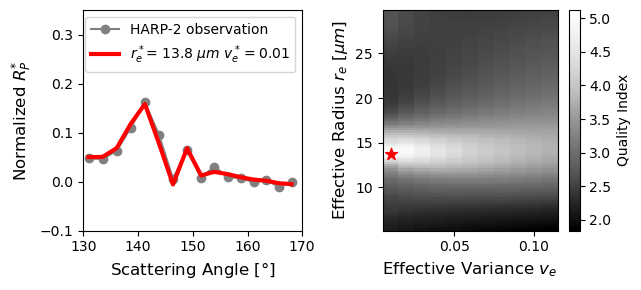

In [36]:
al,ar=10,60
bd_index = 2
sca_range = [130,170]
sca_range_index = (H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar] > sca_range[0]) &\
                  (H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar] < sca_range[1])  
Sca_obs = H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar][sca_range_index]
Rp_obs = H1C_clean.q_s_norm[y0_clean,x0_clean,al:ar][sca_range_index]
Sca_lut = WC_LUT.LUT_par_dict['scattering_angle']

Nre,Nve = WC_LUT.LUT_par_dict['re'].size,WC_LUT.LUT_par_dict['veff'].size

# uncertainty = 0.03 * np.abs(Rp_obs)    # retrieval uncertainty
# uncertainty = np.maximum(0.03 * np.abs(Rp_obs), 0.01)
fig, ax = plt.subplots(1,2,figsize=(6.5,3),tight_layout=True)
ax[0].set_xlim(sca_range)
ax[0].set_ylim([-0.1,0.35])
# ax[0].errorbar(Sca_obs, Rp_obs, yerr=uncertainty, fmt='o', c='gray', ecolor='k', elinewidth=1, capsize=3,
#                label='HARP-2 observation (±3%)')
ax[0].plot(Sca_obs, Rp_obs, marker='o', c='gray', label='HARP-2 observation')

fitting_qual=np.zeros([Nre,Nve])
fitting_par=np.zeros([Nre,Nve,3])

# Loop over all (re, ve) to find best match
for re_index in range(0,Nre):
    for ve_index in range(0,Nve):
        p12_lut   = np.interp(Sca_obs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,ve_index,re_index,:])
        predictor = np.stack((Sca_obs,p12_lut))
        popt, pcov = curve_fit(Rp_mod, predictor, Rp_obs, p0=[-1,-1,0])
        Rp_fit=Rp_mod(predictor,*popt)
        
        fitting_qual[re_index,ve_index]=Qual_index(p12_lut,Rp_obs,Rp_fit)
        fitting_par[re_index,ve_index,:]=popt
Qual=fitting_qual
best_fit_re_index,  best_fit_ve_index =np.unravel_index(fitting_qual.argmax(),fitting_qual.shape)

re_best_fit=WC_LUT.LUT_par_dict['re'][best_fit_re_index]
ve_best_fit=WC_LUT.LUT_par_dict['veff'][best_fit_ve_index] 

print('re best fit',re_best_fit)
print('ve best fit',ve_best_fit)

p12_best_fit= np.interp(Sca_obs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,best_fit_ve_index,best_fit_re_index,:])
Qual_best_fit = fitting_qual[best_fit_re_index ,best_fit_ve_index]
par_best_fit = fitting_par[best_fit_re_index ,best_fit_ve_index,:]
predictor_best_fit=np.stack((Sca_obs,p12_best_fit))
a,b,c=par_best_fit

ax[0].plot(Sca_obs, Rp_mod(predictor_best_fit,a,b,c), c='r',
           label=r'$r_e^*$={0:5.1f} $\mu m$ $v_e^*={1:5.2}$'.format(re_best_fit,ve_best_fit), ls='solid', lw=3.0)
ax[0].set_xlabel(r'Scattering Angle [$\degree$]',fontsize='large')
ax[0].set_ylabel(r'Normalized $R^{*}_P$',fontsize='large')
ax[0].legend(loc='upper right')

ve, re= WC_LUT.LUT_par_dict['veff'], WC_LUT.LUT_par_dict['re']
re_index= (5<re) & (re<30)

cf=ax[1].pcolormesh(ve, re[re_index], np.log(Qual[re_index,:]), cmap='Greys_r')
ax[1].scatter(ve_best_fit, re_best_fit, c='r', marker='*', s=80)
cbar=plt.colorbar(cf, ax=ax[1])
cbar.set_label('Quality Index')
ax[1].set_xlabel(r'Effective Variance $v_e$',fontsize='large')
ax[1].set_ylabel(r'Effective Radius $r_e$ $[\mu m]$',fontsize='large')
plt.tight_layout()

# plt.savefig('HARP2_cloud_microphysics_example_retrieval.png', dpi=500, bbox_inches="tight")

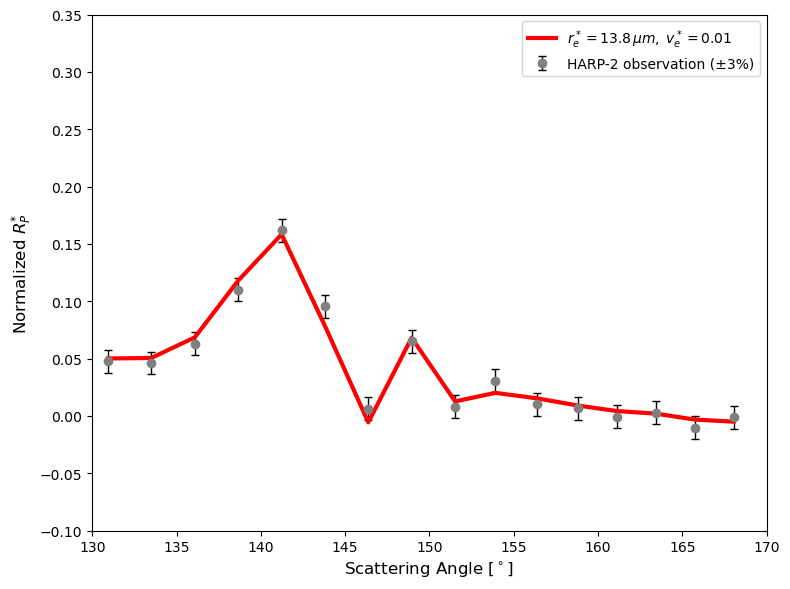

In [37]:
# uncertainty = 0.03 * np.abs(Rp_obs)    # retrieval uncertainty
uncertainty = np.maximum(0.03 * np.abs(Rp_obs), 0.01)

fig, ax = plt.subplots(figsize=(8, 6), tight_layout=True)

ax.set_xlim(sca_range)
ax.set_ylim([-0.1, 0.35])

# plot obs with error bars
ax.errorbar(Sca_obs, Rp_obs, yerr=uncertainty, fmt='o', c='gray', ecolor='k', elinewidth=1, capsize=3,
            label='HARP-2 observation (±3%)')

# best-fit curve
ax.plot(Sca_obs, Rp_mod(predictor_best_fit, a, b, c), c='r', ls='solid', lw=3.0,
        label=rf'$r_e^*={re_best_fit:5.1f}\,\mu m,\; v_e^*={ve_best_fit:5.2f}$')

# labels and legend
ax.set_xlabel(r'Scattering Angle [$^\circ$]', fontsize='large')
ax.set_ylabel(r'Normalized $R^{*}_P$', fontsize='large')
ax.legend(loc='upper right')
plt.tight_layout()

# plt.savefig('HARP2_retrieval_Uncertainty.png', dpi=500, bbox_inches="tight")
plt.show()

## Perform retrievals on all water phase clouds in the granule

### select all the pixels with scattering angle in the 130-155 degree

In [92]:
scattering_angles = H1C_clean.geolocation_data.scattering_angle[:,:,10:70]
scattering_angle_lower_bound = 0
scattering_angle_upper_bound = 160
min_angles = 10

# Create a boolean array where the condition is True if any angle in the 80 directions
# is between 130 and 160 degrees for each latitude and longitude
condition_array = (scattering_angles >= scattering_angle_lower_bound) & \
                  (scattering_angles <= scattering_angle_upper_bound) & \
                   (~np.isnan(scattering_angles))

# Now, reduce the third dimension (80 angles) by taking any True values across the angles
count_array = np.any(condition_array, axis=2)
result = count_array >= min_angles
print(result.shape,np.sum(result))

(396, 519) <xarray.DataArray 'scattering_angle' ()> Size: 8B
array(0)


In [ ]:
M,N,S=H1C_clean.geolocation_data.scattering_angle.values.shape
bd_index = 2
sca_range = [130,160]
al,ar=10,60
Sca_lut = WC_LUT.LUT_par_dict['scattering_angle']
re_best_fit = np.zeros([M,N])
ve_best_fit = np.zeros([M,N])
y0,x0=283,250
dxy=50

re_best_fit=[]
ve_best_fit=[]
for i in range(y0-dxy,y0+dxy):
    print('processing',i)
    for j in range(x0-dxy,x0+dxy):
    
        if np.sum(~np.isnan(H1C_clean.geolocation_data.scattering_angle[i,j,al:ar].values)) <=0: 
            print(H1C_clean.geolocation_data.scattering_angle[i,j,al:ar].values)
            continue
            
        sca_range_index = (H1C_clean.geolocation_data.scattering_angle[i,j,al:ar].values > sca_range[0]) &\
                          (H1C_clean.geolocation_data.scattering_angle[i,j,al:ar].values < sca_range[1]) 
        if np.sum(sca_range_index) <=10: 
            print(H1C_clean.geolocation_data.scattering_angle[i,j,al:ar].values[sca_range_index])
            continue
        Sca_obs = H1C_clean.geolocation_data.scattering_angle[i,j,al:ar].values[sca_range_index]
        Rp_obs = H1C_clean.q_s_norm[i,j,al:ar].values[sca_range_index]
        
        fitting_qual=np.zeros([Nre,Nve])
        fitting_par=np.zeros([Nre,Nve,3])
        for re_index in range(0,Nre):
            for ve_index in range(0,Nve):
                p12_lut   = np.interp(Sca_obs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,ve_index,re_index,:])
                predictor = np.stack((Sca_obs,p12_lut))
                #print(Rp_obs)
                popt, pcov = curve_fit(Rp_mod, predictor, Rp_obs, p0=[-1,-1,0])
                Rp_fit=Rp_mod(predictor,*popt)
                #ax[0].plot(Sca_obs,Rp_fit+0.1)
                fitting_qual[re_index,ve_index]=Qual_index(p12_lut,Rp_obs,Rp_fit)
                fitting_par[re_index,ve_index,:]=popt
        Qual=fitting_qual
        best_fit_re_index,  best_fit_ve_index =np.unravel_index(fitting_qual.argmax(),fitting_qual.shape)
        re_best_fit.append(WC_LUT.LUT_par_dict['re'][best_fit_re_index])
        ve_best_fit.append(WC_LUT.LUT_par_dict['veff'][best_fit_ve_index]) 
        p12_best_fit = np.interp(Sca_obs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,best_fit_ve_index,
                                 best_fit_re_index,:])
        Qual_best_fit = fitting_qual[best_fit_re_index ,best_fit_ve_index]
        par_best_fit = fitting_par[best_fit_re_index ,best_fit_ve_index,:]
        predictor_best_fit=np.stack((Sca_obs,p12_best_fit))
        a,b,c=par_best_fit

processing 233
processing 234
processing 235
processing 236
processing 237
processing 238


In [ ]:
re_best_fit=np.array(re_best_fit).reshape(dxy*2,dxy*2)
ve_best_fit=np.array(ve_best_fit).reshape(dxy*2,dxy*2)

In [ ]:
np.savez(f'HARP2_{HARP2_L1C_clean}_Water_Cloud_retrievals_with_muv_normalization.npz',
        re_retrieval=re_best_fit,ve_retrieval=ve_best_fit, x0=x0, y0=y0, dxy=dxy)

In [ ]:
R = H1C_clean.observation_data.i[y0-dxy:y0+dxy,x0-dxy:x0+dxy,40,0]
G = H1C_clean.observation_data.i[y0-dxy:y0+dxy,x0-dxy:x0+dxy,4,0]
B = H1C_clean.observation_data.i[y0-dxy:y0+dxy,x0-dxy:x0+dxy,84,0]

RGB_max=np.max([np.nanmax(R),np.nanmax(G),np.nanmax(B)])
RGB_min=np.min([np.nanmin(R),np.nanmin(G),np.nanmin(B)])
RGB_scale=(RGB_max-RGB_min)/255.0
RGB=np.stack([(R-RGB_min)/RGB_scale,(G-RGB_min)/RGB_scale,(B-RGB_min)/RGB_scale],axis=2)
RGB_image=np.array(RGB,dtype=np.uint8)

In [ ]:
fig,ax=plt.subplots(1,3,figsize=[12,4],tight_layout=True)
ax[0].imshow(RGB_image)
ax[0].set_title('RGB image',fontsize='large')
re_img=ax[1].imshow(re_best_fit,vmin=5,vmax=20)
ax[1].set_title(r'$r_e$ retrieval',fontsize='large')
plt.colorbar(re_img,ax=ax[1],extend='max')
ve_img=ax[2].imshow(ve_best_fit,vmin=0.01,vmax=0.05,cmap='plasma_r')
ax[2].set_title(r'$v_e$ retrieval',fontsize='large')
plt.colorbar(ve_img,ax=ax[2],extend='max')

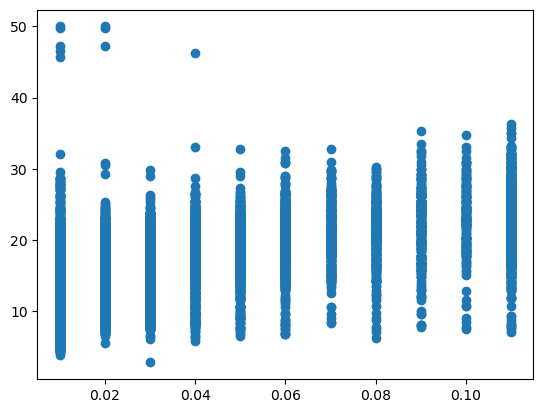

In [48]:
fig,ax=plt.subplots()
ax.scatter(ve_best_fit, re_best_fit)

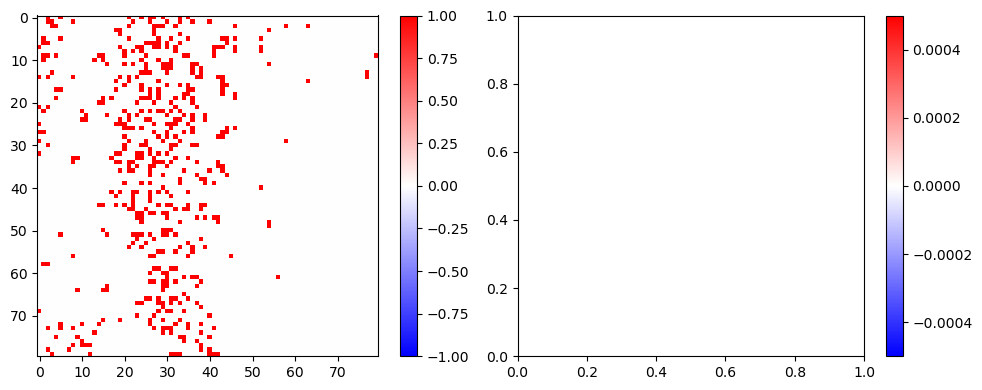

In [42]:
retrieval_no_norm=np.load(f'HARP2_{HARP2_L1C_clean}_Water_Cloud_retrievals_wo_muv_normalization.npz')
fig, ax=plt.subplots(1,2,figsize=[10,4], tight_layout=True)

re_diff_img=ax[0].imshow(re_best_fit-retrieval_no_norm['re_retrieval'] ,vmin=-1, vmax=1, cmap='bwr')
plt.colorbar(re_diff_img,ax=ax[0])

ve_diff_img=ax[0].imshow(ve_best_fit-retrieval_no_norm['ve_retrieval'], vmin=-0.0005, vmax=0.0005, cmap='bwr')
plt.colorbar(ve_diff_img,ax=ax[1])

In [37]:
np.nanmean(ve_best_fit-retrieval_no_norm['ve_retrieval'])

0.0007796875

### Compare the results with OCI Level 2 retrievals

In [30]:
HARP2_L1C_clean = '20240715T190758'

In [31]:
d=np.load(f'HARP2_{HARP2_L1C_clean}_Water_Cloud_retrievals.npz')
x0=d['x0']
y0=d['y0']
dxy=d['dxy']
HARP2_re = d['re_retrieval']

In [32]:
print('x0',x0,'y0',y0,'dxy',dxy)
print(HARP2_re.shape)

x0 400 y0 200 dxy 40
(80, 80)


In [33]:
pixel_latitude = H1C_clean.geolocation_data.latitude.values[y0-dxy:y0+dxy, x0-dxy:x0+dxy]
pixel_longitude = H1C_clean.geolocation_data.longitude.values[y0-dxy:y0+dxy, x0-dxy:x0+dxy]

In [34]:
pixel_latitude.shape

(80, 80)

In [35]:
#print(pixel_latitude[40,40],pixel_longitude[40,40])

In [36]:
oci_pixels = (oci_l1b_granuel.geo.latitude.values <= pixel_latitude.max()) &\
             (oci_l1b_granuel.geo.latitude.values >= pixel_latitude.min()) &\
             (oci_l1b_granuel.geo.longitude.values <= pixel_longitude.max()) &\
             (oci_l1b_granuel.geo.longitude.values >= pixel_longitude.min())
oci_pixels_index = np.where(oci_pixels)

In [37]:
oci_pixels.sum()

83018

In [38]:
#oci_pixel_indices =  np.where(oci_pixels)
oci_cer21 = np.where(  oci_pixels,oci_l2cld_granuel.cld_prop.cer_21.values, np.nan) # oci_l2cld_granuel.cld_prop.cer_21.values[oci_pixel_indices]

In [39]:
oci_cer21.shape

(1710, 1272)

(800.0, 1400.0)

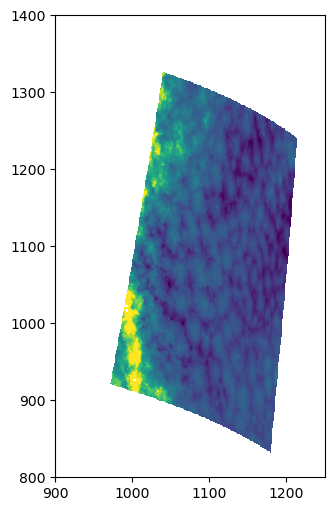

In [40]:
fig,ax=plt.subplots(figsize=(10,6))
ax.imshow(oci_cer21,origin='lower',vmin=HARP2_re.min(),vmax=HARP2_re.max())
ax.set_xlim([900,1250])
ax.set_ylim([800,1400])

[Text(0.5, 1.0, 'Effective Radus Retrieval Comparison'),
 Text(0, 0.5, 'PDF'),
 Text(0.5, 0, 'Effective Radius [um]')]

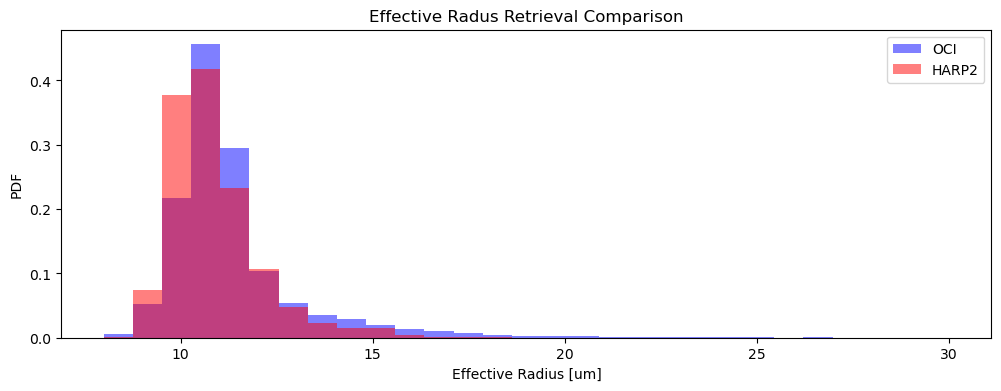

In [41]:
bins = np.linspace(8,30,30)
fig, axes = plt.subplots(figsize=(12,4))
plt.hist(oci_cer21[~np.isnan(oci_cer21)],bins=bins,color='b',alpha=0.5,density=True,label='OCI')
plt.hist(HARP2_re.flatten(),bins=bins,color='r',alpha=0.5,density=True,label='HARP2')
plt.legend()
ax.set_xlim([8,20])
plt.gca().set(title='Effective Radus Retrieval Comparison', ylabel='PDF',xlabel=r'Effective Radius [um]')


In [30]:
HARP2_re.shape

(80, 80)

In [39]:
B=oci_l1b_granuel.obs.rhot_blue[56,:,:].values[oci_pixel_indices]
G=oci_l1b_granuel.obs.rhot_blue[97,:,:].values[oci_pixel_indices]
R=oci_l1b_granuel.obs.rhot_red[20,:,:].values[oci_pixel_indices]

n1,n2=R.shape

RGB=np.zeros([n1,n2,3])
RGB[:,:,0]=R*255
RGB[:,:,1]=G*255
RGB[:,:,2]=B*255
RGB_image=np.array(RGB, dtype=np.uint8)
fig,ax=plt.subplots()
ax.imshow(RGB_image[:,:,:],origin='lower')

ValueError: not enough values to unpack (expected 2, got 1)